# Broadcasting, and Image Processing Using Numpy

In [1]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

## Broadcasting

**What is Broadcasting?**

Broadcasting allows NumPy to perform arithmetic operations on arrays of different sizes. 
It does this by “stretching” the smaller array across the larger array so they have compatible shapes. 
This stretching is not done in memory, meaning that no extra space is used for the larger arrays, 
making broadcasting both memory and computationally efficient.

https://numpy.org/doc/stable/user/basics.broadcasting.html

https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

In [33]:
a = np.array([1,2,3,4,5])
b = np.array([2])
a+b

array([3, 4, 5, 6, 7])

Rules of Broadcasting

Broadcasting in NumPy follows a strict set of rules to determine the interaction between the two arrays:

**Rule 1**: If the arrays don’t have the same number of dimensions, prepend the shape of the smaller array with ones until both shapes have the same length.

**Rule 2**: The size in each dimension of the output shape is the maximum size of the corresponding dimensions of the input arrays.

**Rule 3**: An array can be broadcast across another array if for each trailing dimension (starting from the end), the axis lengths match, or if either of the lengths is 1.

**Rule 4**: Broadcasting is not possible if the above rules are not met, and an error will be raised.

In [34]:
A = np.zeros([3,5])
A 
a = np.zeros(5)
a
print(A.shape, a.shape)
print(A+a)

(3, 5) (5,)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [37]:
A = np.ones((3,5))
B = A.reshape(15)
for entry in B:
    print(entry)

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


In [36]:
a = np.array([0,1,2])
b = np.array([5,5,5])
a + b

array([5, 6, 7])

In [10]:
# broadcasting: "stretching" arrays so that binary operations can be done on arrays of different sizes
print(a+5)
# behind the scenes: numpy stretches out the 5 -> [5, 5, 5]

[5 6 7]


# **You can add a 1D array to every row of a 2D Matri**

In [14]:
# Create a 2D array (matrix) of shape (4, 3)
# Each row represents a set of measurements
M = np.ones([4,3])
print(M, M.shape)
print('\n')

# Create a 1D array of shape (3,)
# This array holds the values to be added to each row of the matrix
a = np.array([1,2,3])
print(a, a.shape)
print('\n')

# Use broadcasting to add the 1D array to every row of the 2D matrix
# a is "broadcasted" to the shape of M
print (M+a)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]] (4, 3)


[1 2 3] (3,)


[[2. 3. 4.]
 [2. 3. 4.]
 [2. 3. 4.]
 [2. 3. 4.]]


# **Broadcasting is adding arrays to arrays**

In [17]:
# Create a 2D array with shape (2, 2)
a1 = np.array([[1,2],[3,4]])
print(a1,a1.shape)
print('\n')
# Create another 2D array with shape (2, 1)
a2 = np.array([[10],[20]])
print(a2,a2.shape)
print('\n')

# Broadcast and add array1 and array2
print(a1+a2)

[[1 2]
 [3 4]] (2, 2)


[[10]
 [20]] (2, 1)


[[11 12]
 [23 24]]


In [14]:
# Create a 2D matrix with shape (4, 3)
matrix = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
# Create a 2D row vector with shape (1, 3)
vector = np.array([100,200,300])
# Broadcast and add the row vector to each row of the matrix
result = matrix + vector
print(result)

[[101 202 303]
 [104 205 306]
 [107 208 309]
 [110 211 312]]


In [38]:
# Create a 2D array (matrix) with shape (2, 3)
matrix1 = np.array([[1,2,3],[4,5,6]])
print(matrix1,'\n')


# Create another 2D array with shape (3, 2)
matrix2 = np.array([[10,20],[30,40],[50,60]])
print(matrix2, '\n')

# Attempt to broadcast and add the two matrices
matrix_1_1 = matrix1.reshape(3,2)
print(matrix_1_1,'\n')

print(matrix_1_1+matrix2)


[[1 2 3]
 [4 5 6]] 

[[10 20]
 [30 40]
 [50 60]] 

[[1 2]
 [3 4]
 [5 6]] 

[[11 22]
 [33 44]
 [55 66]]


## Image Processing Using Numpy

In [25]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

<class 'numpy.ndarray'>
(1200, 1800, 3)


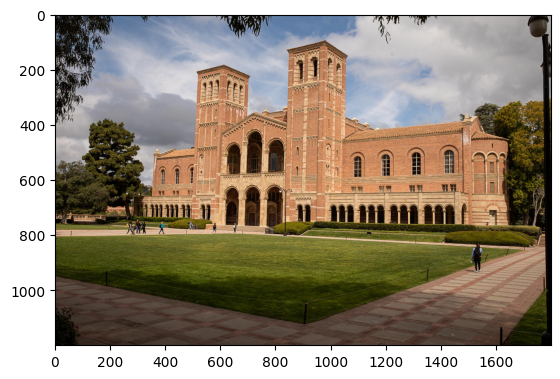

In [26]:
royce = mpimg.imread('royce.jpg')
print(type(royce))
plt.imshow(royce)

print(royce.shape)

How do we interprete those three numbers? Let's use the following plot:

![rgb.png](rgb.png)

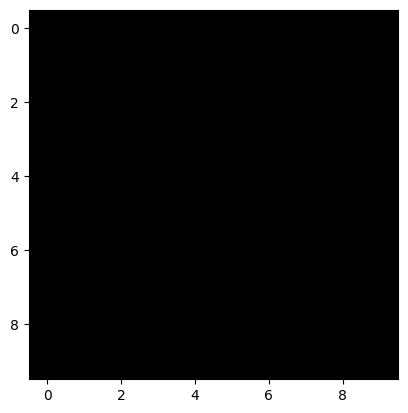

In [27]:
A = np.zeros([10,10,3], dtype = np.uint8)
plt.imshow(A)

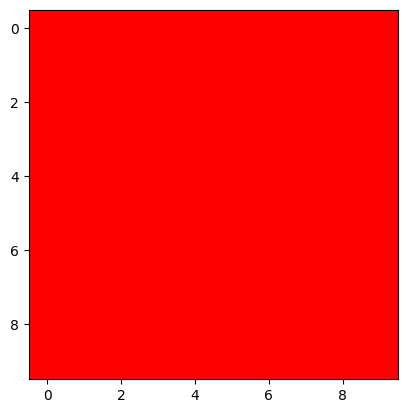

In [28]:
R = A.copy()
R[:,:,0] = 255
plt.imshow(R)

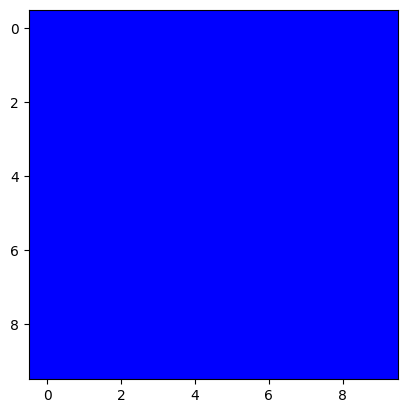

In [29]:
B = A.copy()
B[:,:,2] = 255
plt.imshow(B)

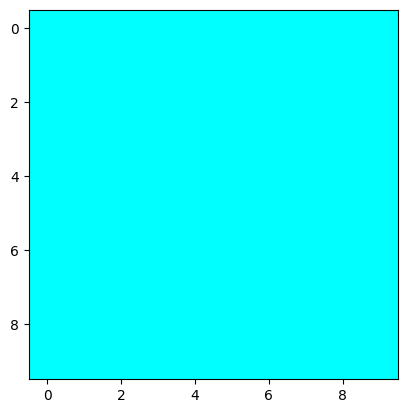

In [30]:
# mix blue and green
C = A.copy()
C[:,:,[1,2]] = 255
plt.imshow(C)

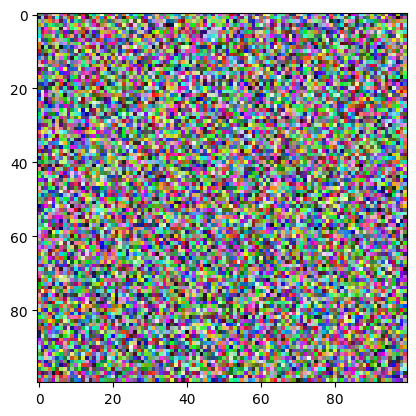

In [26]:
# generate an image of random colors
Red = np.random.choice(range(256), [100,100])
Green = np.random.choice(range(256), [100,100])
Blue = np.random.choice(range(256), [100,100])
A = np.zeros([100,100,3], dtype=np.uint8)
A[:,:,0] = Red
A[:,:,1] = Green
A[:,:,2] = Blue
plt.imshow(A)

<class 'numpy.ndarray'>


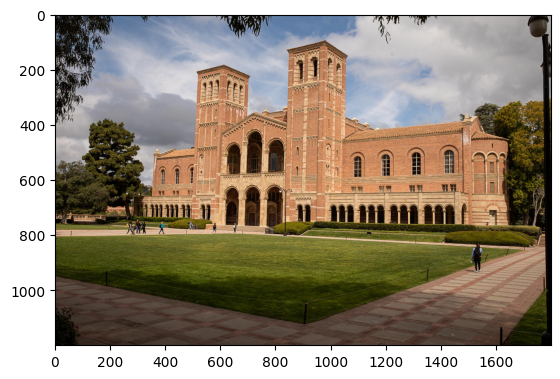

In [27]:
# crop image
royce = mpimg.imread('royce.jpg')
print(type(royce))
plt.imshow(royce)

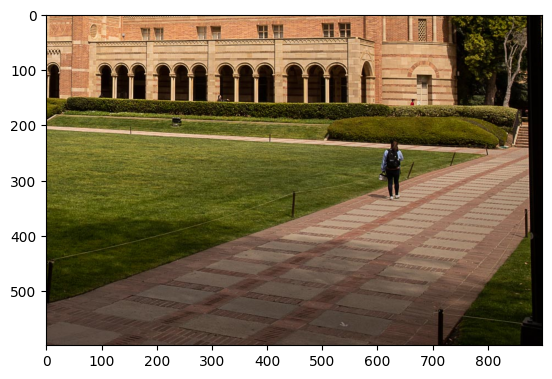

In [28]:
A = royce[601:1200,901:1800,:]
plt.imshow(A)

<class 'numpy.ndarray'> (112, 140, 3)


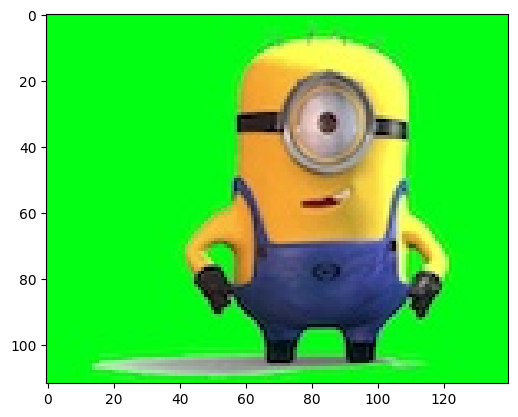

In [29]:
m= mpimg.imread('minion.jpg')
print(type(m), m.shape)
plt.imshow(m)

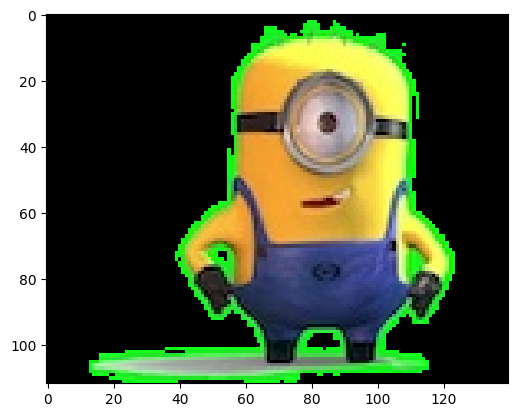

In [30]:
m = np.copy(m)
mask = (m[:,:,0] <= 10) & (m[:,:,2] <= 50) & (m[:,:,1] >= 245)
m[mask] = [0,0,0]
plt.imshow(m)

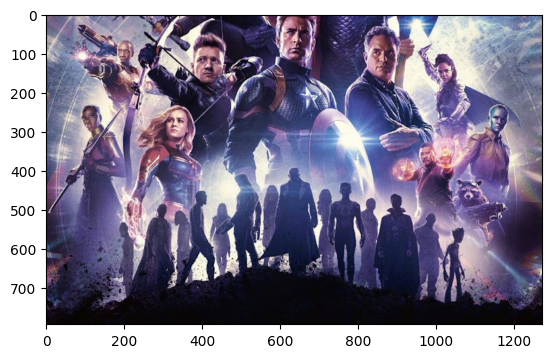

In [31]:
a = mpimg.imread('avengers.jpg')
plt.imshow(a)

In [32]:
a = np.copy(a)
print(a.shape)

(794, 1272, 3)


In [35]:
a[a.shape[0]-m.shape[0]:, a.shape[1]//2-m.shape[1]//2: a.shape[1]//2+m.shape[1]//2, :] = m

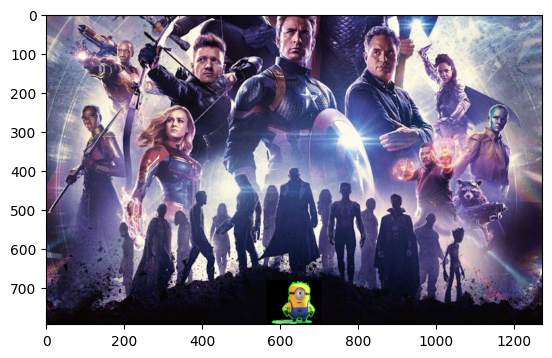

In [36]:
plt.imshow(a)

# **hi**

In [41]:
import numpy as np 
L=[1,2,3]
a= np.array([1,2,3])
print(L+[4])
print(a+4)

[1, 2, 3, 4]
[5 6 7]


In [44]:
import numpy as np 

M = np.array([[1,2,3],[4,5,6]])
print(M, '\n')
v = np.array([[10],[20]])
print(v, '\n')

print(M+v)

[[1 2 3]
 [4 5 6]] 

[[10]
 [20]] 

[[11 12 13]
 [24 25 26]]


In [49]:
import numpy as np 

a = np.array([3,4,5,6,7,8])
print(a[(a>=5) & (a%2 == 0)])
print(a[[2,3]])

print(a != 0)

[6 8]
[5 6]
[ True  True  True  True  True  True]
